# 02 · Diwali Impact on AQI

**Question:** Is AQI higher during Diwali than in the days around it?

**Method**
1. For each year, take the 5 days around Diwali (2 days before to 2 days after) as the **festival period**.
2. Take the 7 days before and the 7 days after as the **comparison periods**.
3. **Impact = festival average − average of the before and after weeks.**

AQI naturally rises through October and November. If we compared only with the week before, the festival would look worse just because it comes later in the season. Using both sides cancels out most of that seasonal rise.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, "aqi_master_clean.csv"), parse_dates=['Date'])
df.head()

,Date,AQI,City,Month,Year,AQI_Bucket
0,2019-01-01,118,Bengaluru,1,2019,Moderate
1,2019-01-02,92,Bengaluru,1,2019,Satisfactory
2,2019-01-03,93,Bengaluru,1,2019,Satisfactory
3,2019-01-04,104,Bengaluru,1,2019,Moderate
4,2019-01-05,102,Bengaluru,1,2019,Moderate


## 1. Diwali dates

In [4]:
# Main Diwali day for each year
diwali_dates = {
    2019: '2019-10-27',
    2020: '2020-11-14',
    2021: '2021-11-04',
    2022: '2022-10-24',
    2023: '2023-11-12',
    2024: '2024-10-31',
}

In [6]:
windows = []

for year, date in diwali_dates.items():
    diwali = pd.Timestamp(date)
    temp = df[(df['Date'] >= diwali - pd.Timedelta(days=9)) &
              (df['Date'] <= diwali + pd.Timedelta(days=9))].copy()
    temp['Diwali_Year'] = year
    temp['Day'] = (temp['Date'] - diwali).dt.days
    windows.append(temp)

window_df = pd.concat(windows)

def label_period(day):
    if day < -2:
        return 'Before'
    elif day <= 2:
        return 'During'
    else:
        return 'After'

window_df['Period'] = window_df['Day'].apply(label_period)
window_df[['City', 'Date', 'Diwali_Year', 'Day', 'Period', 'AQI']].head(10)

,City,Date,Diwali_Year,Day,Period,AQI
290,Bengaluru,2019-10-18,2019,-9,Before,50
291,Bengaluru,2019-10-19,2019,-8,Before,55
292,Bengaluru,2019-10-20,2019,-7,Before,50
293,Bengaluru,2019-10-21,2019,-6,Before,52
294,Bengaluru,2019-10-22,2019,-5,Before,56
295,Bengaluru,2019-10-23,2019,-4,Before,49
296,Bengaluru,2019-10-24,2019,-3,Before,41
297,Bengaluru,2019-10-25,2019,-2,During,50
298,Bengaluru,2019-10-26,2019,-1,During,45
299,Bengaluru,2019-10-27,2019,0,During,62


## 2. Impact for each city and year

In [8]:
summary = window_df.pivot_table(
    index=['City', 'Diwali_Year'],
    columns='Period',
    values='AQI',
    aggfunc='mean'
)[['Before', 'During', 'After']]

baseline = (summary['Before'] + summary['After']) / 2
summary['Impact'] = summary['During'] - baseline
summary['Impact_Pct'] = summary['Impact'] / baseline * 100

summary = summary.round(1).reset_index()
summary.to_csv(os.path.join(RESULTS_DIR, "diwali_summary.csv"), index=False)
summary

Period,City,Diwali_Year,Before,During,After,Impact,Impact_Pct
0,Bengaluru,2019,50.4,64.2,80.4,-1.2,-1.9
1,Bengaluru,2020,78.1,53.2,58.7,-15.2,-22.3
2,Bengaluru,2021,87.0,58.2,85.9,-28.2,-32.7
3,Bengaluru,2022,57.3,113.6,89.0,40.5,55.3
4,Bengaluru,2023,48.9,114.6,95.6,42.4,58.7
5,Bengaluru,2024,96.1,121.2,79.4,33.4,38.1
6,Delhi,2019,236.6,335.2,419.6,7.1,2.2
7,Delhi,2020,428.0,344.6,254.4,3.4,1.0
8,Delhi,2021,251.4,379.6,416.1,45.8,13.7
9,Delhi,2022,232.0,281.8,378.9,-23.6,-7.7


## 3. Summary per city

- `Avg_Impact`: average impact over all 6 years
- `Avg_Impact_Excl_2020`: the same without 2020 (pandemic year)
- `Years_Positive`: in how many of the 6 years the festival period was worse than the weeks around it

In [10]:
city_summary = summary.groupby('City').agg(
    Avg_Impact=('Impact', 'mean'),
    Avg_Impact_Pct=('Impact_Pct', 'mean'),
    Years_Positive=('Impact', lambda s: (s > 0).sum()),
)

city_summary['Avg_Impact_Excl_2020'] = (
    summary[summary['Diwali_Year'] != 2020].groupby('City')['Impact'].mean()
)

city_summary = city_summary.round(1)
city_summary.to_csv(os.path.join(RESULTS_DIR, "diwali_city_summary.csv"))
city_summary

,Avg_Impact,Avg_Impact_Pct,Years_Positive,Avg_Impact_Excl_2020
City,,,,
Bengaluru,12.0,15.9,3,17.4
Delhi,-16.7,-4.2,3,-20.7
Kolkata,5.6,7.6,3,15.8
Mumbai,9.2,9.3,4,11.3


## 4. Plots

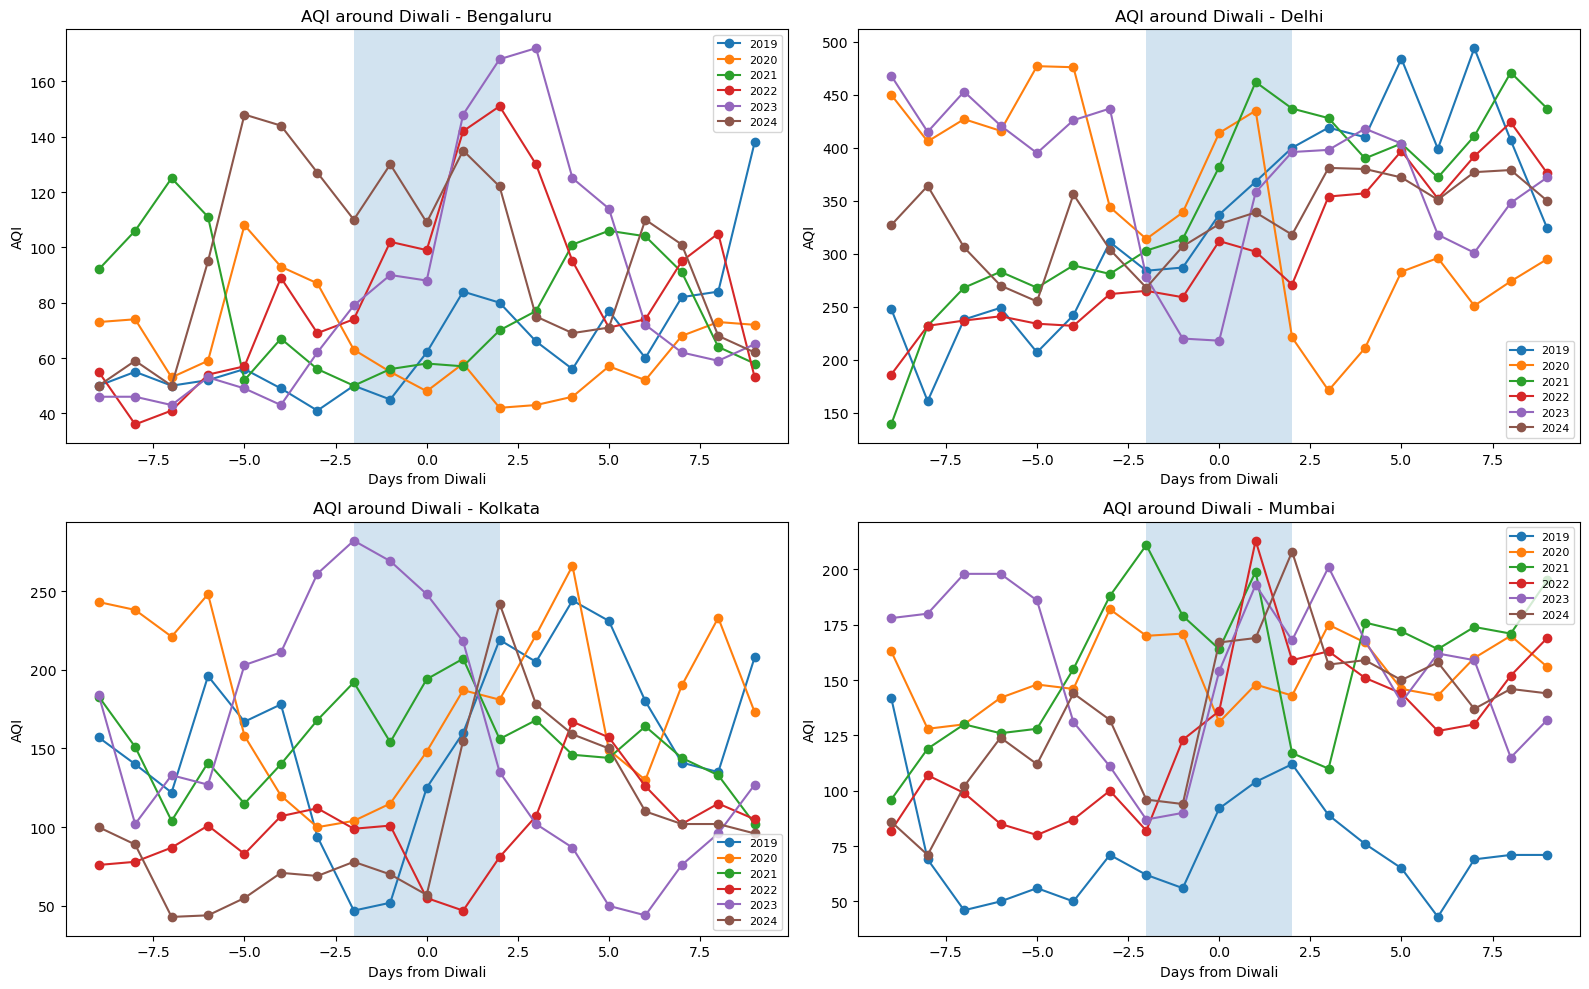

In [12]:
# Daily AQI around Diwali, one line per year
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (city, city_data) in zip(axes.flat, window_df.groupby('City')):
    for year, year_data in city_data.groupby('Diwali_Year'):
        ax.plot(year_data['Day'], year_data['AQI'], marker='o', label=year)
    ax.axvspan(-2, 2, alpha=0.2)
    ax.set_title(f'AQI around Diwali - {city}')
    ax.set_xlabel('Days from Diwali')
    ax.set_ylabel('AQI')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

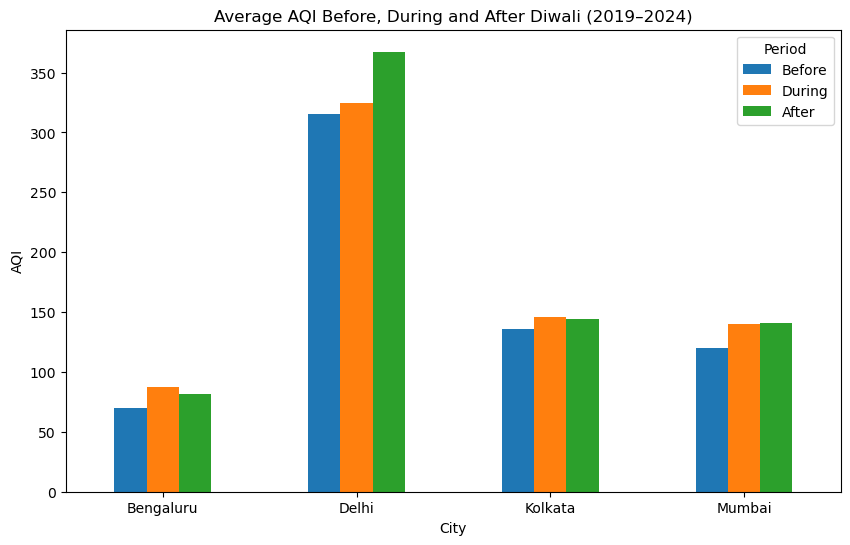

In [13]:
# Average AQI before, during and after Diwali (averaged over all years)
period_avg = summary.groupby('City')[['Before', 'During', 'After']].mean()

period_avg.plot(kind='bar', figsize=(10, 6))
plt.title('Average AQI Before, During and After Diwali (2019–2024)')
plt.ylabel('AQI')
plt.xticks(rotation=0)
plt.show()

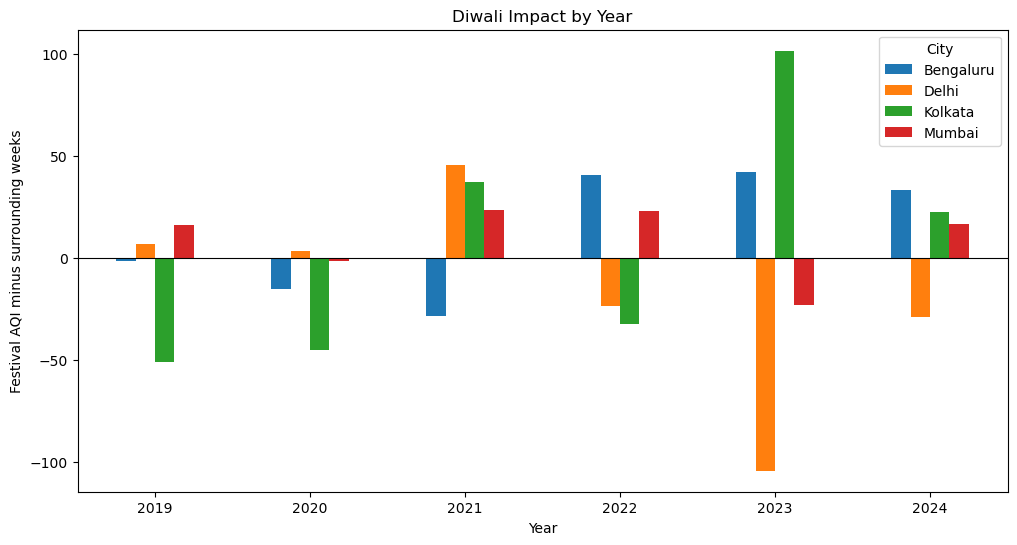

In [14]:
# Impact in each year: above zero = festival period worse than the weeks around it
impact_table = summary.pivot(index='Diwali_Year', columns='City', values='Impact')

impact_table.plot(kind='bar', figsize=(12, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Diwali Impact by Year')
plt.ylabel('Festival AQI minus surrounding weeks')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.show()